# LAB 4 Linear Regression & Its Variants

## Part 1: Loading a Real Dataset – California Housing


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print(f"Dataset Shape: {df.shape}")
print(f"\nFeature names: \n{housing.feature_names}")
print(f"\nFirst 5 rows: \n{df.head()}")
print(f"\nBasic statistics: \n{df.describe().round(3)}")

Dataset Shape: (20640, 9)

Feature names: 
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows: 
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics: 
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1

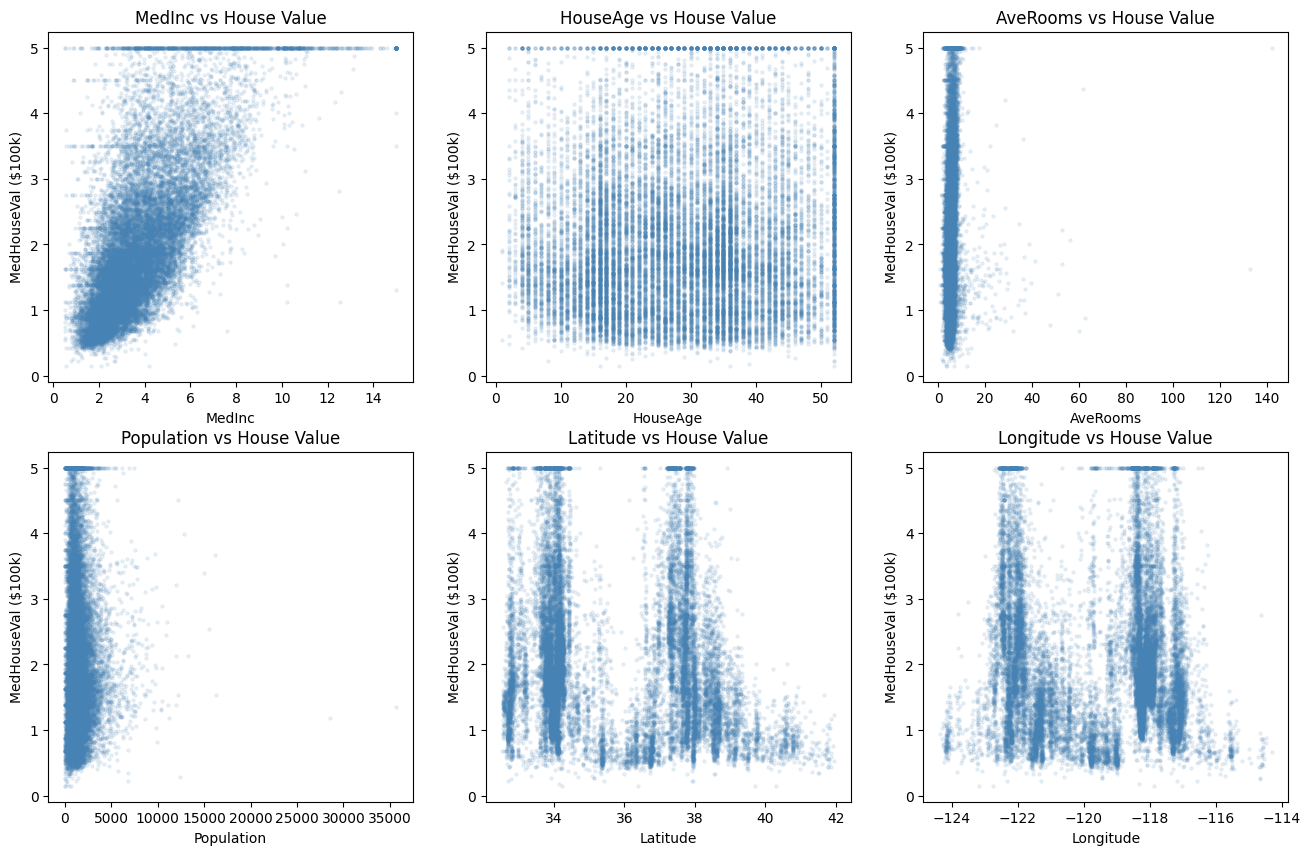

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))
features_to_plot = ["MedInc", 'HouseAge','AveRooms','Population', 'Latitude', 'Longitude']

for ax, feat in zip(axes.flatten(), features_to_plot):
  ax.scatter(df[feat], df['MedHouseVal'], alpha=0.1, s=5, color='steelblue')
  ax.set_xlabel(feat)
  ax.set_ylabel('MedHouseVal ($100k)')
  ax.set_title(f'{feat} vs House Value')

plt.tight_layout
plt.show()

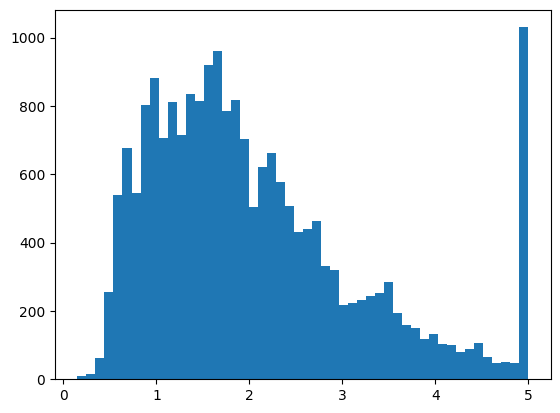

In [4]:
"""
Task 1: Explore the Dataset
- Use df.corr()[’MedHouseVal’].sort values() to rank features by their correlation with the target. Which feature has the strongest correlation?

ANS: MedInc has the strongest correlation.

- Plot the distribution of MedHouseVal using plt.hist(df[’MedHouseVal’],
bins=50). Is the target normally distributed? Do you notice any cap at $5.0
(i.e., $500,000)?

ANS: The graph is not normally distributed, but right-skewed, and the dataset is capped at $5.0 or $500,000

- How many samples are in the dataset? Is this enough for training a good model?

ANS: There are 20,640 samples, which is more than enough to train a good model
"""

df.corr()['MedHouseVal'].sort_values()

plt.hist(df['MedHouseVal'], bins=50)
plt.show()

## Part 2: Simple Linear Regression (One Feature)

In [5]:
from sklearn.model_selection import train_test_split

X_simple = df[['MedInc']].values
y=df['MedHouseVal'].values

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16512
Testing samples: 4128


Slope (w1): 0.4193
Intercept (w0): 0.4446

Equation: y = 0.4193 * MedInc + 0.4446


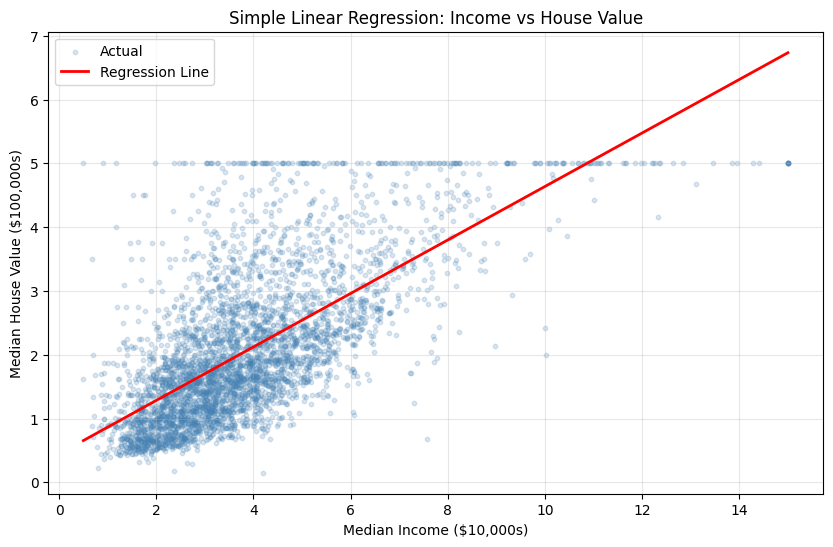

In [6]:
from sklearn.linear_model import LinearRegression

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print(f'Slope (w1): {model_simple.coef_[0]:.4f}')
print(f'Intercept (w0): {model_simple.intercept_:.4f}')
print(f'\nEquation: y = {model_simple.coef_[0]:.4f} * MedInc + {model_simple.intercept_:.4f}')

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.2, s=10, color='steelblue', label='Actual')

x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: Income vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Task 2: Interpret the Simple Model

* What are the slope and intercept your model learned? Write the equation.

ANS:

slope = 0.4193

y_intercept = 0.4446

y = 0.4193x + 0.4446

* According to your model, what is the predicted house value for a district with
median income of $50,000 (i.e., MedInc = 5.0)? Calculate by hand and verify with
model simple.predict([[5.0]]).

y = 0.4193(5.0) + 0.4446 = 2.5411
* Try training a simple model using HouseAge instead of MedInc. Is it better or
worse? Why?


As shown below, training the model on HouseAge is worse due to the weaker correlation to MedHouseVal than MedInc



In [7]:
model_simple.predict([[5.0]])

array([2.54128976])

Training samples: 16512
Testing samples: 16512
Slope (w1): 0.0095
Intercept (w0): 1.7998

Equation: y = 0.0095 * MedInc + 0.4446


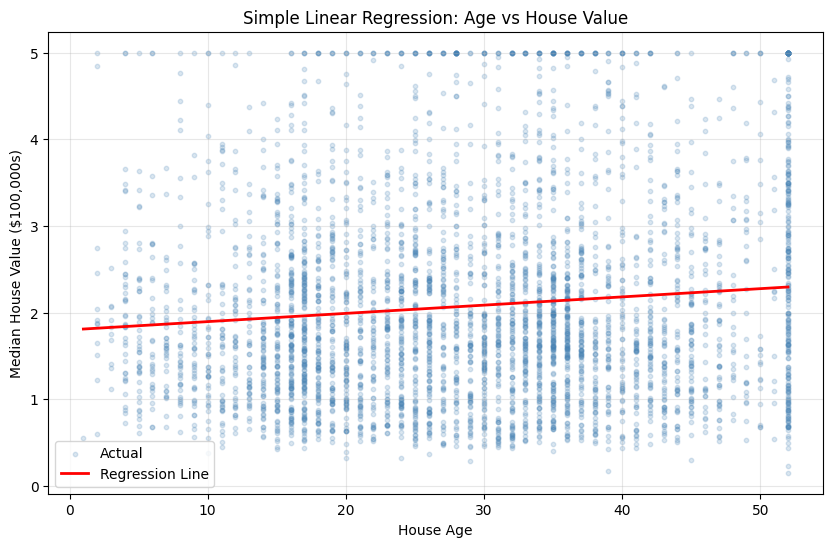

In [8]:
X_age = df[['HouseAge']].values
y=df['MedHouseVal'].values

X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(X_age, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train_age.shape[0]}')
print(f"Testing samples: {X_train_age.shape[0]}")

model_age = LinearRegression()
model_age.fit(X_train_age, y_train_age)

print(f'Slope (w1): {model_age.coef_[0]:.4f}')
print(f'Intercept (w0): {model_age.intercept_:.4f}')
print(f'\nEquation: y = {model_age.coef_[0]:.4f} * MedInc + {model_simple.intercept_:.4f}')

plt.figure(figsize=(10, 6))
plt.scatter(X_test_age, y_test_age, alpha=0.2, s=10, color='steelblue', label='Actual')
x_line = np.linspace(X_test_age.min(), X_test_age.max(), 100)
y_line = model_age.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel('House Age')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: Age vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 3: Evaluating Regression Models

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_simple = model_simple.predict(X_test)

mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print("=== Simple Linear Regression (MedInc only) ===")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}  (error in $100,000 s)")
print(f"MAE: {mae:.4f}  (error in $100,000 s)")
print(f"R^2: {r2:.4f}  ({r2*100:.1f}% variance explained)")


=== Simple Linear Regression (MedInc only) ===
MSE: 0.7091
RMSE: 0.8421  (error in $100,000 s)
MAE: 0.6299  (error in $100,000 s)
R^2: 0.4589  (45.9% variance explained)


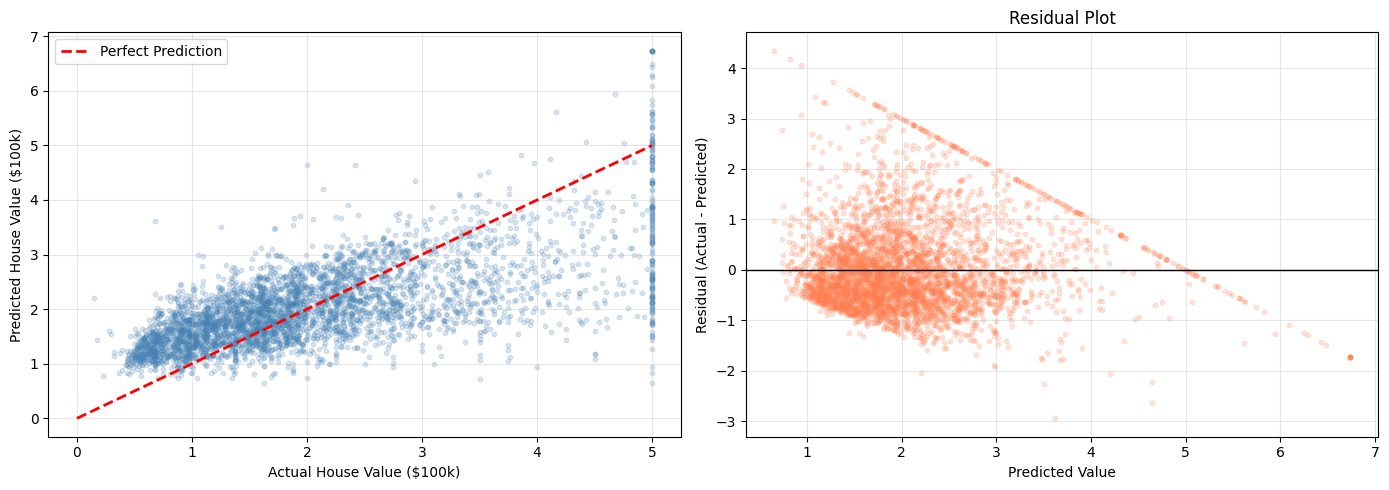

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10, color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 3: Understand the Metrics
 Convert the RMSE to actual dollars. If RMSE ≈ 0.74, what is the average prediction error in dollars?
*  74,000 dollars, so the average prediction has an error of $74,000.

Look at the “Predicted vs Actual” plot. Where does the model struggle most – at
low values, high values, or both?

* The model struggles most at high house values, where predictions become more dispersed and less accurate. This indicates the model cannot capture the behavior of expensive houses well.

What does the R2 value tell you? Is a single feature enough to predict house prices
well?

* The R2 score shows that the model explains 45.9% of the variation.

## Part 4: Multiple Linear Regression (All Features)

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_lr.fit(X_train,y_train)
y_pred_multi = pipe_lr.predict(X_test)

r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print(f'=== Multiple Linear Regression (all 8 features) ===')
print(f'RMSE: {rmse_multi:.4f}')
print(f'R^2: {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)')
print(f'\nImprovement over simple model:\nR^2: {r2:.4f} -> {r2_multi:.4f}'
      f'(+{(r2_multi - r2)*100:.1f}%)')

=== Multiple Linear Regression (all 8 features) ===
RMSE: 0.7456
R^2: 0.5758 (57.6% variance explained)

Improvement over simple model:
R^2: 0.4589 -> 0.5758(+11.7%)


Feature Importance (by |coefficient|):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


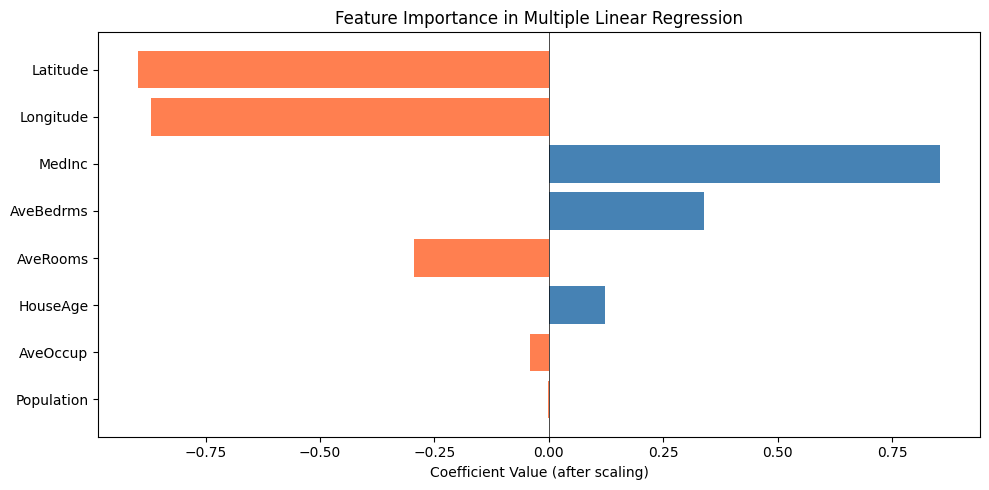

In [12]:
lr_model = pipe_lr.named_steps['lr']
feature_names = housing.feature_names

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f'Feature Importance (by |coefficient|):\n{coef_df.to_string(index=False)}')

plt.figure(figsize=(10,5))
colors = ['steelblue' if c>0 else 'coral'
          for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (after scaling)')
plt.title('Feature Importance in Multiple Linear Regression')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

List the top 3 most important features and the bottom 3. Does this make intuitive
sense?

* Top 3 are Latitude, longitude, and Income. Bottom 3 are HouseAge, Occupation, and population. This makes sense since the location and income is the deciding factor for most people when buying a house.

Why does Latitude have a negative coefficient? What does this mean geographically for California?

* In California:
Lower latitude → Southern California (e.g., San Diego, LA)
Higher latitude → Northern California (toward Oregon). So, houses tend to be more expensive in the south and cheaper in the north (on average).

Create the “Predicted vs Actual” plot for the multiple regression model. Compare
it visually with the simple model. Is it closer to the diagonal?

* Yes, the model is more accurate and closer to the diagonal.

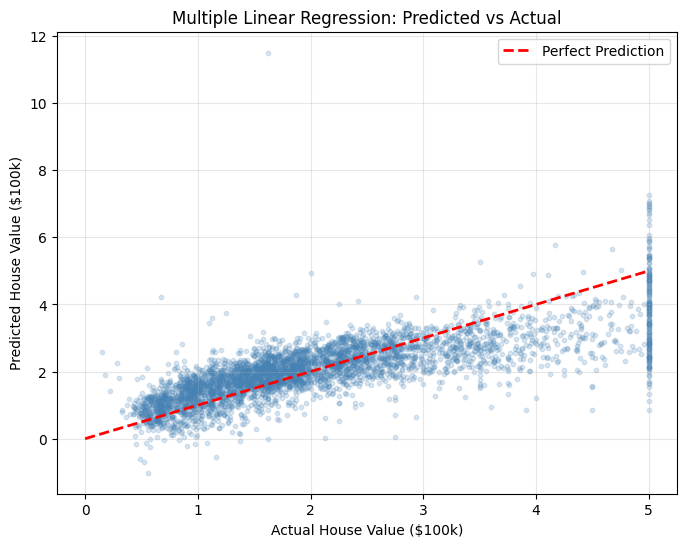

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10, color='steelblue')

plt.plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual House Value ($100k)')
plt.ylabel('Predicted House Value ($100k)')
plt.title('Multiple Linear Regression: Predicted vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 5: Polynomial Regression

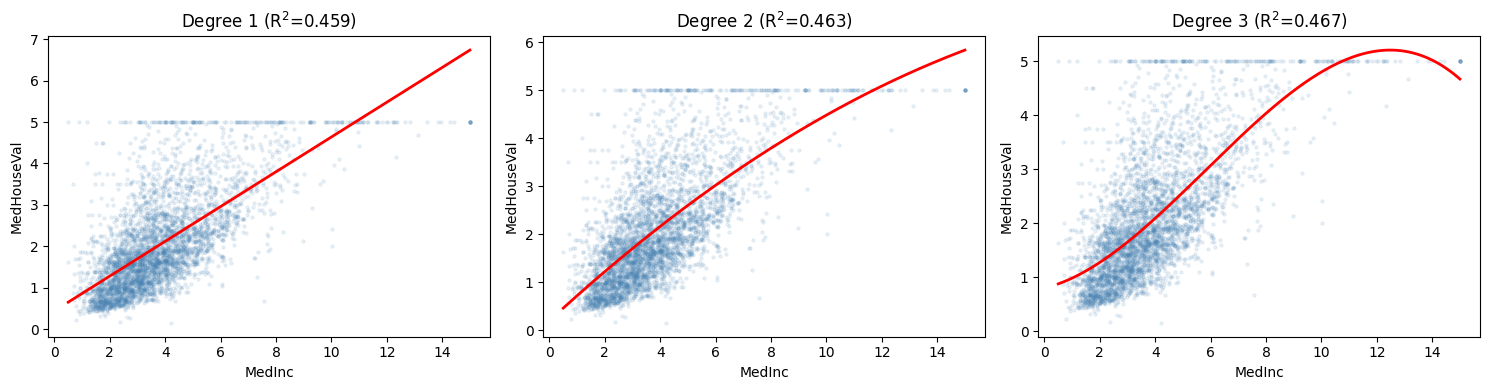

Polynomial Degree Comparison (MedInc only):
Degree 1: R^2=0.4589, RMSE=0.8421
Degree 2: R^2=0.4633, RMSE=0.8386
Degree 3: R^2=0.4671, RMSE=0.8356


In [14]:
from sklearn.preprocessing import PolynomialFeatures

X_train_s, X_test_s, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

results = {}
plt.figure(figsize=(15,4))

for i, degree in enumerate([1,2,3]):
  pipe_poly = Pipeline([
      ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
      ('lr', LinearRegression())
  ])
  pipe_poly.fit(X_train_s, y_train)
  y_pred = pipe_poly.predict(X_test_s)

  r2_val = r2_score(y_test, y_pred)
  rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
  results[degree] = {"R2": r2_val, 'RMSE': rmse_val}

  ax = plt.subplot(1, 3, i+1)
  ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')
  x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1,1)
  y_plot = pipe_poly.predict(x_plot)
  ax.plot(x_plot, y_plot, color='red', linewidth=2)
  ax.set_title(f'Degree {degree} (R$^2$={r2_val :.3f})')
  ax.set_xlabel('MedInc')
  ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

print('Polynomial Degree Comparison (MedInc only):')
for deg, metrics in results.items():
  print(f"Degree {deg}: R^2={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}")

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly_all.fit(X_train,y_train)
y_pred_poly = pipe_poly_all.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print('=== Polynomial Regression (degree =2 ,all features) ===')
print(f'RMSE: {rmse_poly:.4f}')
print(f'R2: {r2_poly:.4f} ({r2_poly*100:.1f}& variance explained)')

poly_features = pipe_poly_all.named_steps['poly']
print('\nOriginal Features: 8')
print(f"After degree-2 expansion: {poly_features.n_output_features_}")

=== Polynomial Regression (degree =2 ,all features) ===
RMSE: 0.6814
R2: 0.6457 (64.6& variance explained)

Original Features: 8
After degree-2 expansion: 44


### Task 5: Explore Polynomial Regression
Look at the three plots for degrees 1, 2, and 3. Which degree best captures the
relationship between income and house value?

* Degree 3 captures the relationship best between income and house value

Try degree 5 on the single-feature model. Does R2 keep improving, or does it start
to behave strangely at the edges? This is overfitting!

* When using degree 5, the model begins to overfit the data. Although R² may increase slightly, the curve behaves strangely at the edges.

How many features does degree 3 create from 8 original features? Use PolynomialFeatures(degree=3).fit transform(X train).shape to check.
* 164 features

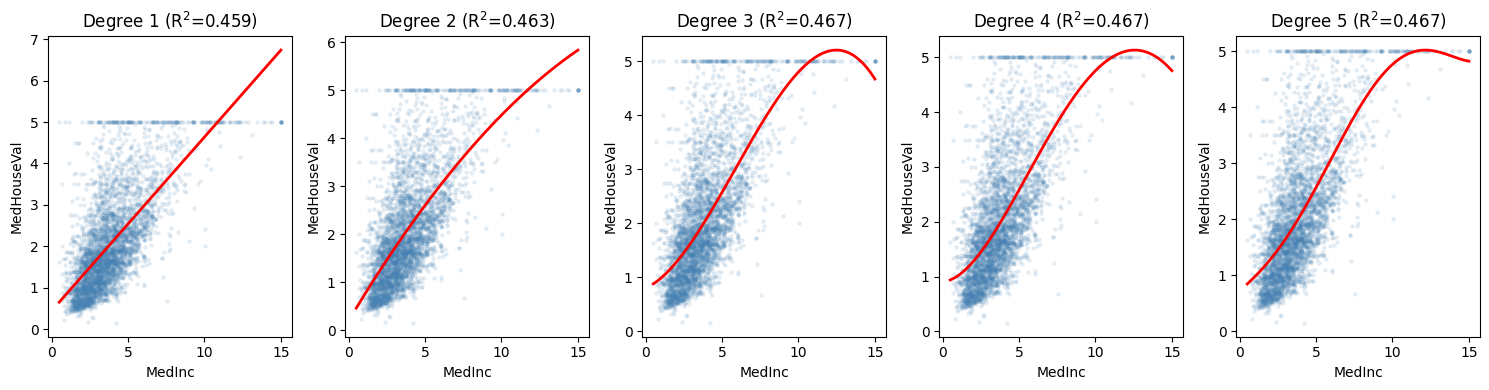

Polynomial Degree Comparison (MedInc only):
Degree 1: R^2=0.4589, RMSE=0.8421
Degree 2: R^2=0.4633, RMSE=0.8386
Degree 3: R^2=0.4671, RMSE=0.8356
Degree 4: R^2=0.4673, RMSE=0.8355
Degree 5: R^2=0.4668, RMSE=0.8359


In [16]:
from sklearn.preprocessing import PolynomialFeatures

X_train_s, X_test_s, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

results = {}
plt.figure(figsize=(15,4))

for i, degree in enumerate([1,2,3,4,5]):
  pipe_poly = Pipeline([
      ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
      ('lr', LinearRegression())
  ])
  pipe_poly.fit(X_train_s, y_train)
  y_pred = pipe_poly.predict(X_test_s)

  r2_val = r2_score(y_test, y_pred)
  rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
  results[degree] = {"R2": r2_val, 'RMSE': rmse_val}

  ax = plt.subplot(1, 5, i+1)
  ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')
  x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1,1)
  y_plot = pipe_poly.predict(x_plot)
  ax.plot(x_plot, y_plot, color='red', linewidth=2)
  ax.set_title(f'Degree {degree} (R$^2$={r2_val :.3f})')
  ax.set_xlabel('MedInc')
  ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

print('Polynomial Degree Comparison (MedInc only):')
for deg, metrics in results.items():
  print(f"Degree {deg}: R^2={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}")

In [17]:
PolynomialFeatures(degree=3).fit_transform(X_train).shape

(16512, 165)

## Part 6: Regularized Regression – Ridge, Lasso, and ElasticNet

In [18]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge (alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, random_state=42))
    ]),
    'ElasticNet (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    ])
}

print(f"{'Model':<28} {'RMSE':>8} {'MAE':>8} {'R^2':>8}")
print('-'*56)

results_dict = {}
for name, pipe in models.items():
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

  rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
  mae_val = mean_absolute_error(y_test, y_pred)
  r2_val = r2_score(y_test, y_pred)

  results_dict[name] = {
      'RMSE': rmse_val, 'MAE': mae_val, 'R2': r2_val
  }
  print(f"{name:<28} {rmse_val:>8.4f} {mae_val:>8.4f} {r2_val:>8.4f}")

Model                            RMSE      MAE      R^2
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge (alpha=1.0)              0.7456   0.5332   0.5758
Lasso (alpha=0.01)             0.7404   0.5353   0.5816
ElasticNet (alpha=0.01)        0.7416   0.5341   0.5803


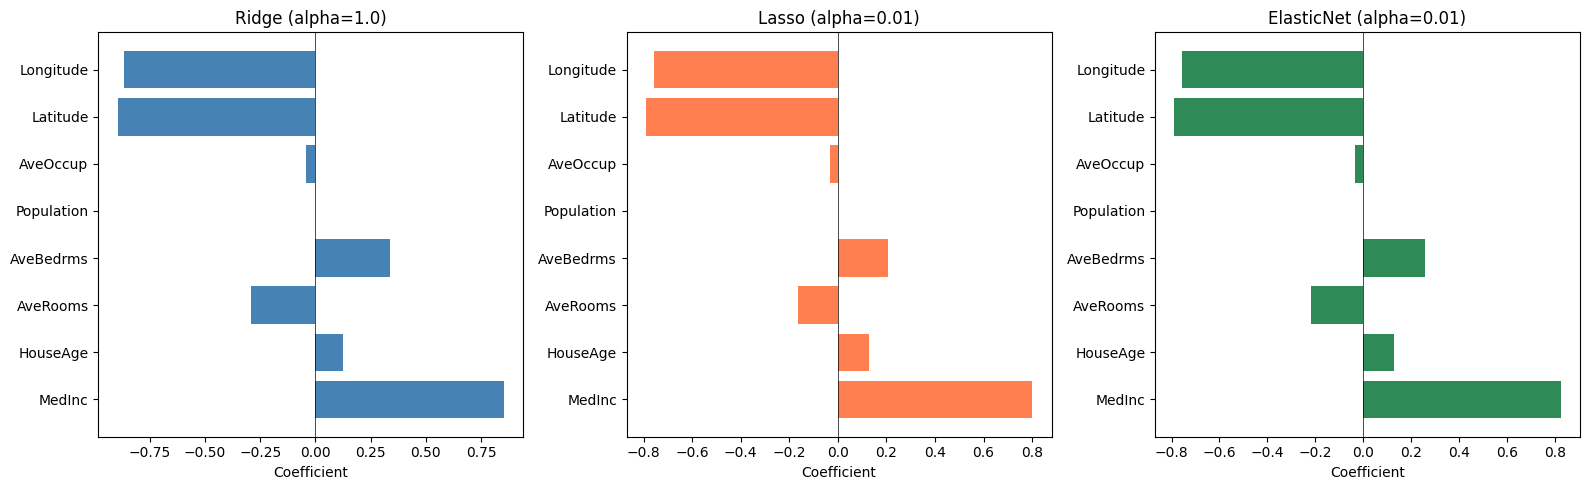


Lasso coefficients:
 MedInc      :   0.8010
 HouseAge    :   0.1271
 AveRooms    :  -0.1628
 AveBedrms   :   0.2062
 Population  :  -0.0000<-- REMOVED
 AveOccup    :  -0.0306
 Latitude    :  -0.7901
 Longitude   :  -0.7557


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = ['Ridge (alpha=1.0)',
               'Lasso (alpha=0.01)',
               'ElasticNet (alpha=0.01)']
colors_list = ['steelblue', 'coral', 'seagreen']

for ax, name, clr in zip(axes, model_names, colors_list):
  coefs = models[name].named_steps['model'].coef_
  ax.barh(housing.feature_names, coefs, color=clr)
  ax.set_title(name)
  ax.axvline(x=0, color='black', linewidth=0.5)
  ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

lasso_coefs = models['Lasso (alpha=0.01)'].named_steps['model'].coef_
print('\nLasso coefficients:')
for feat, coef in zip(housing.feature_names, lasso_coefs):
  status = ''if abs(coef) > 0.001 else '<-- REMOVED'
  print(f' {feat:12s}: {coef:>8.4f}{status}')

### Task 6: Explore Regularization
Try different α values for Ridge: 0.01, 0.1, 1.0, 10.0, 100.0. Plot R2 vs α. What
happens with very large α?

* As α increases, the model becomes more regularized, shrinking coefficients toward zero. For very large α values, the model underfits the data, causing R² to decrease significantly.

For Lasso, try alpha=0.1. How many features are removed (coefficient = 0)?
Which ones?

* With α = 0.1, Lasso removes several features by setting their coefficients to zero. This demonstrates its ability to perform feature selection by eliminating less important variables.

In the ElasticNet, change l1 ratio from 0.0 to 1.0. At l1 ratio=0.0, what model
does it become? At l1 ratio=1.0?

* When l1_ratio = 0.0, ElasticNet behaves like Ridge regression, applying only L2 regularization. When l1_ratio = 1.0, it becomes equivalent to Lasso regression, applying only L1 regularization and performing feature selection.

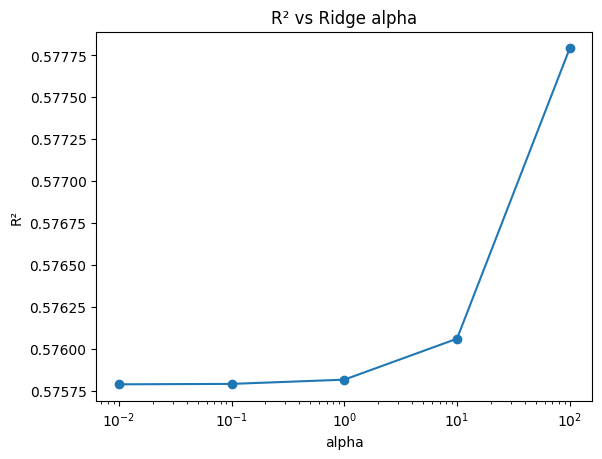

In [20]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
r2_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

plt.plot(alphas, r2_scores, marker='o')
plt.xscale('log')  # important!
plt.xlabel('alpha')
plt.ylabel('R²')
plt.title('R² vs Ridge alpha')
plt.show()

In [21]:
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1))
])

lasso.fit(X_train, y_train)

coefs = lasso.named_steps['model'].coef_

removed = [i for i, c in enumerate(coefs) if abs(c) < 1e-6]

print("Removed feature indices:", removed)
print("Number removed:", len(removed))

Removed feature indices: [2, 3, 4, 5, 7]
Number removed: 5


In [22]:
ratios = [0.0, 0.25, 0.5, 0.75, 1.0]

for r in ratios:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=r))
    ])

    model.fit(X_train, y_train)
    r2 = r2_score(y_test, model.predict(X_test))
    print(f'l1_ratio={r} → R²={r2:.4f}')

c:\Users\hakim\.conda\envs\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.465e+03, tolerance: 2.207e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


l1_ratio=0.0 → R²=0.5784
l1_ratio=0.25 → R²=0.5794
l1_ratio=0.5 → R²=0.5803
l1_ratio=0.75 → R²=0.5811
l1_ratio=1.0 → R²=0.5816


## Part 7: The Alpha Tuning Experiment

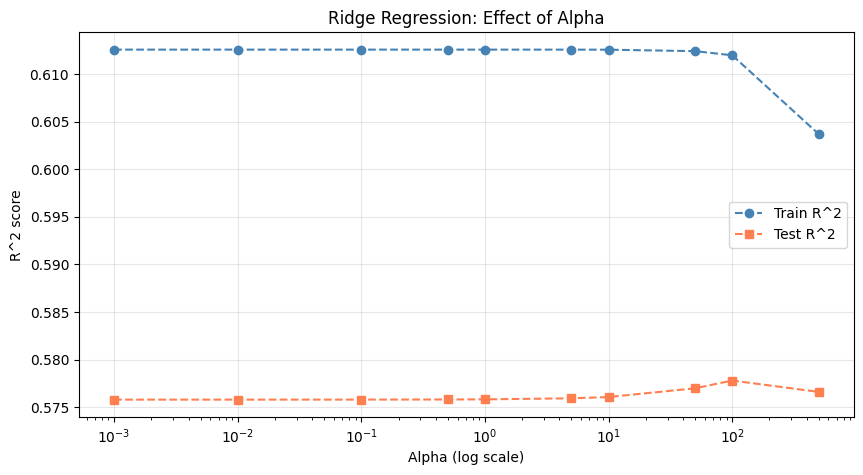

Best alpha: 100.0
Best test R^2: 0.5778


In [23]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]

train_scores = []
test_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, pipe.predict(X_train)))
    test_scores.append(r2_score(y_test, pipe.predict(X_test)))

plt.figure(figsize=(10,5))
plt.semilogx(alphas, train_scores, 'o--', label='Train R^2', color='steelblue')
plt.semilogx(alphas, test_scores, 's--', label='Test R^2', color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 score')
plt.title('Ridge Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_idx = np.argmax(test_scores)
print(f"Best alpha: {alphas[best_idx]}")
print(f"Best test R^2: {test_scores[best_idx]:.4f}")

### Part 8: The Alpha Tuning Experiment
Repeat the alpha search experiment for Lasso using alphas: [0.0001, 0.001,
0.005, 0.01, 0.05, 0.1, 0.5, 1.0]. Plot train and test R2 vs alpha, just like the Ridge plot above.
 * shown in the code below

For each alpha, count how many features Lasso keeps (coefficient ̸= 0). At what
alpha does Lasso start removing features aggressively?

* from alpha=0.05 and increasing, it starts removing features aggressively

Which alpha gives the best test R2
for Lasso?
* alpha = 0.01


alpha=0.0001 → features kept: 8
alpha=0.001  → features kept: 8
alpha=0.005  → features kept: 7
alpha=0.01   → features kept: 7
alpha=0.05   → features kept: 4
alpha=0.1    → features kept: 3
alpha=0.5    → features kept: 1
alpha=1.0    → features kept: 0


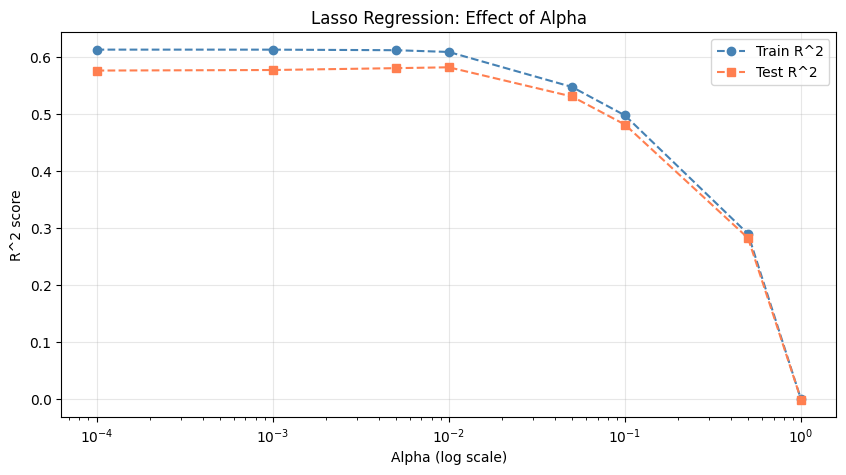

Best alpha: 0.01
Best test R^2: 0.5816


In [24]:
# Task 7
alphas = [0.0001, 0.001,0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

train_scores = []
test_scores = []
nonzero_counts = []
for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)

    coefs = pipe.named_steps['lasso'].coef_
    count_nonzero = np.sum(coefs != 0)
    nonzero_counts.append(count_nonzero)

    train_scores.append(r2_score(y_train, pipe.predict(X_train)))
    test_scores.append(r2_score(y_test, pipe.predict(X_test)))

    print(f"alpha={alpha:<6} → features kept: {count_nonzero}")
    
plt.figure(figsize=(10,5))
plt.semilogx(alphas, train_scores, 'o--', label='Train R^2', color='steelblue')
plt.semilogx(alphas, test_scores, 's--', label='Test R^2', color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 score')
plt.title('Lasso Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_idx = np.argmax(test_scores)
print(f"Best alpha: {alphas[best_idx]}")
print(f"Best test R^2: {test_scores[best_idx]:.4f}")

## Part 9: Final Model Comparison

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

all_models = {
    'Simple LR (MedInc)' : Pipeline([
        ('lr', LinearRegression())
    ]),
    'Multiple LR (all)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),
    'Polynomial (deg=2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('lr', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5))
    ]),
}

print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R^2':>8} {'# Features':>20}")
print('='*67)

comparison_data = []
for name, pipe in all_models.items():
    if 'Simple' in name:
        X_tr = X_train[:, [0]]
        X_te = X_test[:, [0]]
    else:
        X_tr, X_te = X_train, X_test
    
    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)
    
    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        n_feat = 1
    else:
        n_feat = X_train.shape[1]
    
    comparison_data.append({
        'Model': name, 'RMSE':rmse_v, 'MAE':mae_v, 'R2': r2_v, 'Features': n_feat
    })
    print(f"{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {n_feat:>15}")

Model                         RMSE      MAE      R^2           # Features
Simple LR (MedInc)          0.8421   0.6299   0.4589               1
Multiple LR (all)           0.7456   0.5332   0.5758               8
Polynomial (deg=2)          0.6814   0.4670   0.6457              44
Ridge                       0.7456   0.5332   0.5758               8
Lasso                       0.7404   0.5353   0.5816               8
ElasticNet                  0.7416   0.5341   0.5803               8


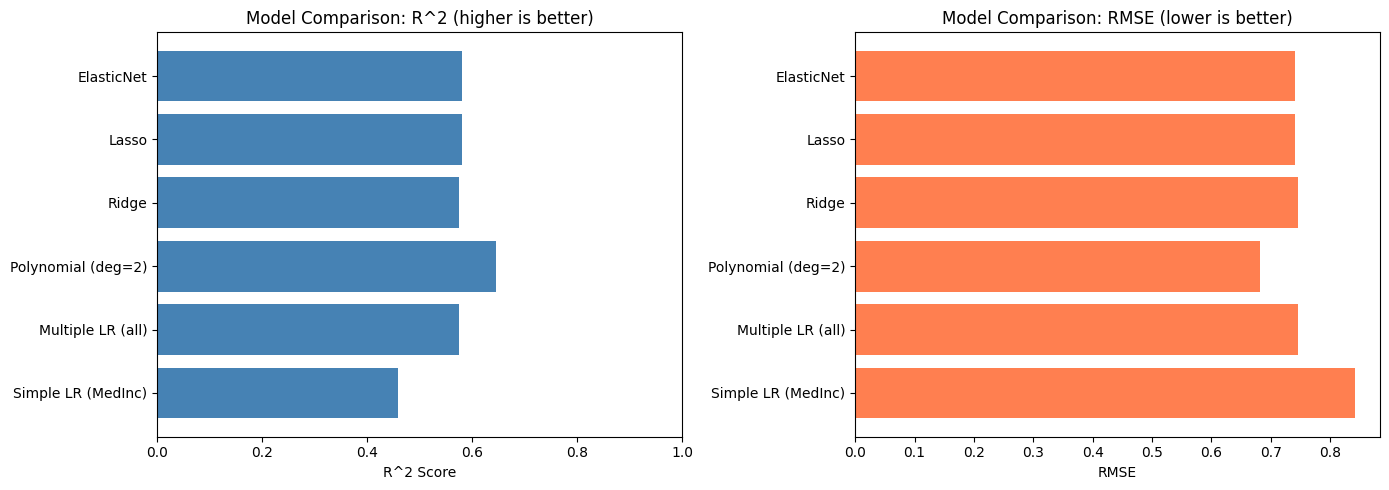

In [26]:
comp_df = pd.DataFrame(comparison_data)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comp_df['Model'], comp_df['R2'], color='steelblue')
axes[0].set_xlabel('R^2 Score')
axes[0].set_title('Model Comparison: R^2 (higher is better)')
axes[0].set_xlim(0,1)

axes[1].barh(comp_df['Model'], comp_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')

plt.tight_layout()
plt.show()

### Task 8: Draw Conclusions

Which model achieved the best R2 on the test set? Which had the lowest RMSE?
* The polynomial model had the best R2 and the lowest RMSE.

The Polynomial (degree 2) model uses 44 features. Is the improvement in R2 worth
the added complexity? Justify your answer.
* It is worth it if we want the highest prediction accuracy. In this housing example however, interpretability and simplicity might be of higher priority to real estate agents to get clear insights. 

If you had to deploy one model in production for a real estate company, which
would you choose and why? Consider accuracy, interpretability, and simplicity.

* Multiple LR would be ideal for interpretability and simplicity with a moderate tradeoff for accuracy (R2 score: 0.5758(Multiple LR) vs 0.6457 (Poly))

Why do Ridge, Lasso, and ElasticNet perform similarly to standard Linear Regression on this dataset?
* Regularization is most helpful when there are many features or strong correlations. Here, the dataset is small (8 features) and clean, so the effect is small.

## Part 9: Apply to a New Dataset – Saudi Housing

In [27]:
np.random.seed(42)
n=500

cities = np.random.choice(
    ['Jeddah', 'Riyadh', 'Dammam', 'Makkah', 'Madinah'],
    n, p=[0.30, 0.30, 0.15, 0.15, 0.10])

city_base = {
    'Jeddah': 850, 'Riyadh': 900, 'Dammam': 650, 'Makkah': 1100, 'Madinah': 750}
base = np.array([city_base[c] for c in cities], dtype=float)

area = np.round(np.random.uniform(80, 400, n), 1)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 40, n)
floor = np.random.randint(1, 15, n)
has_parking = np.random.choice([0,1], n, p=[0.3, 0.7])

price = ( base
+ 3.5 * area
+ 80 * bedrooms
+ 50 * bathrooms
- 12 * age
+ 15 * floor
+ 100 * has_parking
+ np.random.normal(0,150,n))
price = np.round(np.maximum(price, 200), 1)

df_saudi = pd.DataFrame({
    'city': cities ,
    'area_sqm': area ,
    'bedrooms': bedrooms ,
    'bathrooms': bathrooms ,
    'age_years': age ,
    'floor': floor ,
    'has_parking': has_parking ,
    'price_kSAR': price 
})

df_saudi.to_csv('saudi_housing.csv', index=False)
print(f'Dataset shape: {df_saudi.shape}')
print(df_saudi.head(10))
print(f"\nPrice Statistics (thousands SAR):\n{df_saudi['price_kSAR'].describe().round(1)}")

Dataset shape: (500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   
5   Jeddah     132.0         5          4         17     13            1   
6   Jeddah     371.5         6          2          2      6            0   
7   Makkah     343.2         6          3         38      1            1   
8   Dammam     383.9         1          3         10     11            1   
9   Dammam     312.2         2          1         38     13            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
5      2264.8  
6      2821.1  
7      2532

## Task 9: Full Saudi Housing Analysis (Challenge)

price_kSAR     1.00
area_sqm       0.73
bedrooms       0.30
bathrooms      0.09
floor          0.07
has_parking    0.02
age_years     -0.37
Name: price_kSAR, dtype: float64


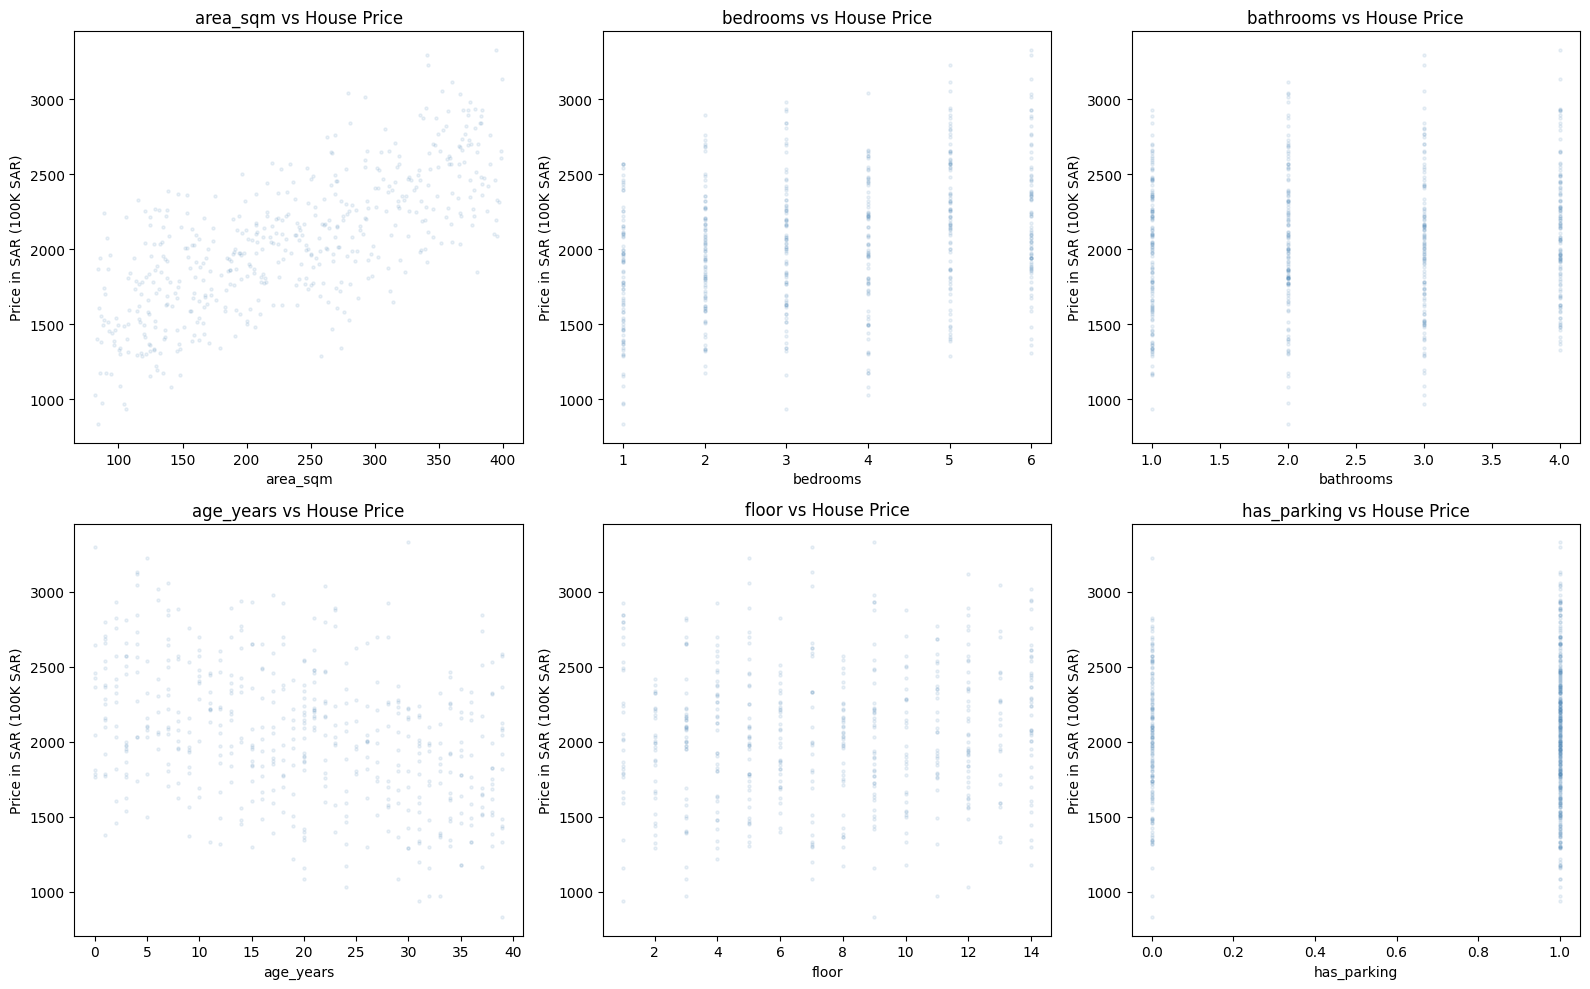

In [36]:
# 1. Explore: Use df.describe(), df.corr(), and scatter plots to understand the
#    data. Which feature correlates most with price?
df_saudi.describe()
numeric_cols = [
    'area_sqm',
    'bedrooms',
    'bathrooms',
    'age_years',
    'floor',
    'has_parking', 
    'price_kSAR',
]
target_cols = 'price_kSAR'
corr = df_saudi[numeric_cols].corr()['price_kSAR'].sort_values(ascending=False)
print(corr.round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, feat in zip(axes.flatten(), numeric_cols):
    ax.scatter(df_saudi[feat], df_saudi['price_kSAR'], alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel("Price in SAR (100K SAR)")
    ax.set_title(f"{feat} vs House Price")

plt.tight_layout()
plt.show()
#area_sqm correlates most with the price

In [40]:
# 2. Preprocess: Encode the city column using One-Hot encoding (from Lab 3). Scale
# the numeric features.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_cols = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']
categ_cols = ['city']
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categ_cols)
])


R2 (Simple LR - area only): 0.5816


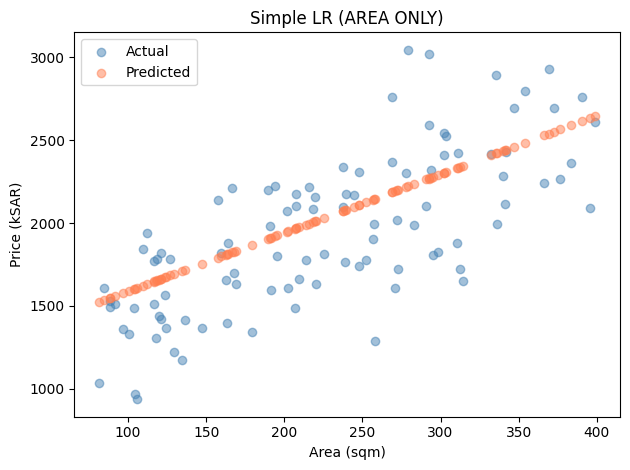

In [41]:
# 3. Simple model: Train a Linear Regression using only area sqm. Plot the regression
# line and report R2

simple_preprocessor = ColumnTransformer([
    ('area_sqm', StandardScaler(), ['area_sqm'])
])
pipe_ksa = Pipeline([
    ('preprocessor', simple_preprocessor),
    ('model', LinearRegression())
])

X_ksa = df_saudi[['area_sqm']]
y_ksa = df_saudi['price_kSAR']
X_train, X_test, y_train, y_test = train_test_split(X_ksa, y_ksa, test_size=0.2, random_state=42)
pipe_ksa.fit(X_train, y_train)
y_pred_ksa = pipe_ksa.predict(X_test)

r2_ksa = r2_score(y_test, y_pred_ksa)
print(f"R2 (Simple LR - area only): {r2:.4f}")

plt.scatter(X_test['area_sqm'].values, y_test, alpha=0.5, color='steelblue', label='Actual')
plt.scatter(X_test['area_sqm'].values, y_pred_ksa, alpha=0.5, color='coral', label='Predicted')

plt.xlabel("Area (sqm)")
plt.ylabel("Price (kSAR)")
plt.title("Simple LR (AREA ONLY)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 4. Multiple model: Train with all features. How much does R2 improve?
numeric_cols = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']
categ_cols = ['city']
X_all = df_saudi[numeric_cols + categ_cols]

y_all = df_saudi['price_kSAR']

X_tr_all, X_te_all, y_tr_all, y_te_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

pipe_ksa_all = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipe_ksa_all.fit(X_tr_all, y_tr_all)
y_pred_all = pipe_ksa_all.predict(X_te_all)

r2_ksa_all = r2_score(y_te_all, y_pred_all)
print(f"Simple R2 (area only): {r2_ksa:.4f}")
print(f"Multiple R2 (all features): {r2_ksa_all:.4f}")
print(f"Improvement: {(r2_ksa_all - r2_ksa)*100:.2f}%")

Simple R2 (area only): 0.4932
Multiple R2 (all features): 0.8645
Improvement: 37.14%


In [52]:
ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge.fit(X_tr_all, y_tr_all)
y_pred_ridge = ridge.predict(X_te_all)
r2_ridge = r2_score(y_te_all, y_pred_all)

lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.1))
])

lasso.fit(X_tr_all, y_tr_all)
y_pred_lasso = lasso.predict(X_te_all)
r2_lasso = r2_score(y_te_all, y_pred_lasso)

elastic = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(alpha=0.1, l1_ratio=0.5))
])

elastic.fit(X_tr_all, y_tr_all)
y_pred_elastic = elastic.predict(X_te_all)
r2_elastic = r2_score(y_te_all, y_pred_elastic)

print("=== R² Scores ===")
print(f"Simple LR (area only): {r2_ksa:.4f}")
print(f"Multiple LR (all features): {r2_ksa_all:.4f}")
print(f"Ridge: {r2_ridge:.4f}")
print(f"Lasso: {r2_lasso:.4f}")
print(f"ElasticNet: {r2_elastic:.4f}")

=== R² Scores ===
Simple LR (area only): 0.4932
Multiple LR (all features): 0.8645
Ridge: 0.8645
Lasso: 0.8644
ElasticNet: 0.8214


In [ ]:
# 6. Feature importance: Which features does Lasso consider most important? Does
# this match your intuition about Saudi housing prices?

# ANS: it makes sense that each city affects greatly on the price and the area of the house as well.
coeffs = lasso.named_steps['model'].coef_
feature_names = (
    numeric_cols +
    list(lasso.named_steps['preprocessor']
         .named_transformers_['cat']
         .get_feature_names_out(categ_cols))
)
lasso_importance = pd.Series(coeffs, index=feature_names)
lasso_importance = lasso_importance.sort_values(key=abs, ascending=False)

print(lasso_importance.round(2))

city_Makkah     510.68
area_sqm        333.84
city_Riyadh     274.41
city_Jeddah     222.34
bedrooms        142.18
age_years      -127.97
city_Madinah    123.36
floor            73.93
bathrooms        53.85
has_parking      42.05
dtype: float64


Simple LR (area only)       334.67   276.06   0.4932               1
Multiple LR (all features)   173.03   137.30   0.8645               7
Polynomial LR (deg=2)       178.20   138.34   0.8563              65
Ridge                       173.87   138.65   0.8632               7
Lasso                       173.04   137.31   0.8645               7
ElasticNet                  175.12   140.10   0.8612               7


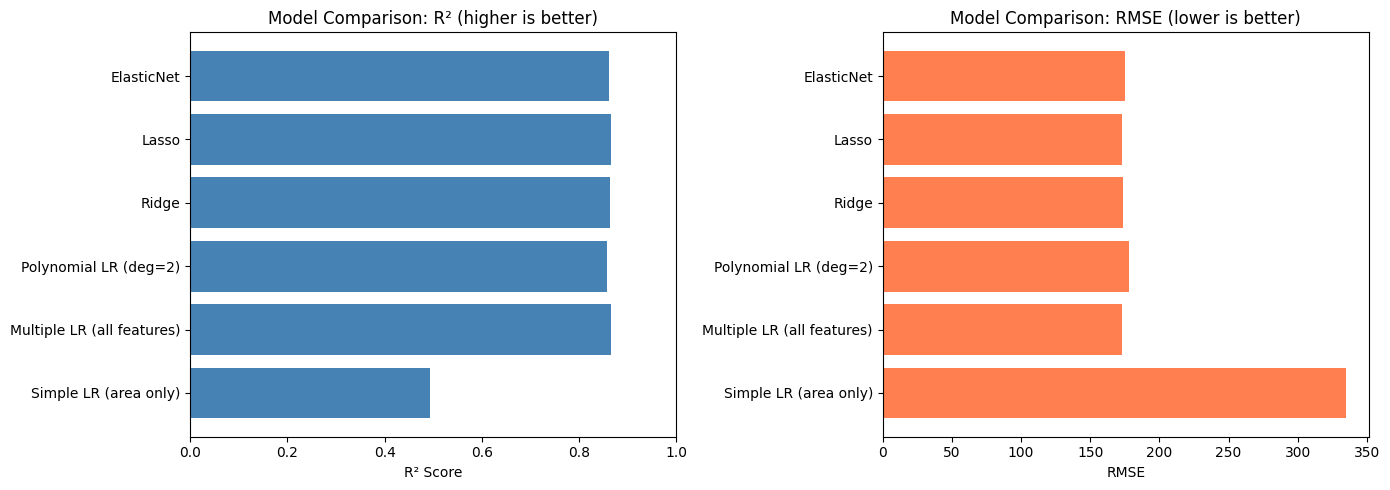

In [ ]:
# 7. Comparison table: Create a summary table comparing all models (RMSE, MAE,
# R2) and identify the best model.


numeric_cols = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']
categ_cols = ['city']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categ_cols)
])

X_all = df_saudi[numeric_cols + categ_cols]
y_all = df_saudi['price_kSAR']
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

all_models = {
    'Simple LR (area only)': Pipeline([
        ('preprocessor', ColumnTransformer([
            ('area', StandardScaler(), ['area_sqm'])
        ])),
        ('model', LinearRegression())
    ]),
    'Multiple LR (all features)': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),
    'Polynomial LR (deg=2)': Pipeline([
        ('preprocessor', preprocessor),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1.0))
    ]),
    'Lasso': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Lasso(alpha=0.01, max_iter=10000))
    ]),
    'ElasticNet': Pipeline([
        ('preprocessor', preprocessor),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))
    ])
}

comparison_data = []

for name, pipe in all_models.items():
    # Special handling for Simple LR (area only)
    if 'Simple' in name:
        X_tr = X_train[['area_sqm']]
        X_te = X_test[['area_sqm']]
    else:
        X_tr, X_te = X_train, X_test
    
    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)
    
    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)
    
    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        n_feat = 1
    else:
        n_feat = X_tr.shape[1]
    
    comparison_data.append({
        'Model': name, 'RMSE': rmse_v, 'MAE': mae_v, 'R2': r2_v, 'Features': n_feat
    })
    
    print(f"{name:<25} {rmse_v:>8.2f} {mae_v:>8.2f} {r2_v:>8.4f} {n_feat:>15}")

comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comp_df['Model'], comp_df['R2'], color='steelblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model Comparison: R² (higher is better)')
axes[0].set_xlim(0,1)

axes[1].barh(comp_df['Model'], comp_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')

plt.tight_layout()
plt.show()

### Report 

The Polynomial Regression (degree 2) model was the best regression model trained on the California housing data as it had the highest R 2 indicating that it was able to model the nonlinear relationships within the data as compared to simple linear regression models. Simple Linear Regression with MedInc alone had an approximate percentage of 46 explaining the variance, whereas multiple linear regression with all features had an approximate percentage of 57. Regularizations such as Ridge, Lasso, ElasticNet marginally improved R 2 and helped to avoid overfitting; Lasso also dropped some less informative variables, emphasizing the most informative ones. MedInc, Latitude, and Longitude were the most significant characteristics that affected the prices of houses whereas Population and AveOccup did not significantly affect the prices. The expansion of the features into a poly boosted the interactions between features, enhancing the accuracy of the model, but making it less interpretable. In general, the combination of all the applicable numeric and geographic characteristics with certain levels of the expansion of the polynomials provided the best predictive performance, and the regularization was used to stabilize the model coefficients.